# **Medical Insurance Cost Prediction**
## __Exploratary Data Analysis__

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Load Dataset

In [2]:
df=pd.read_csv("../data/insurance.csv")
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


## Dataset overview

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Data Quality Assessment

In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df["sex"].unique() #checking inconsistent values

<StringArray>
['female', 'male']
Length: 2, dtype: str

## checking outliers

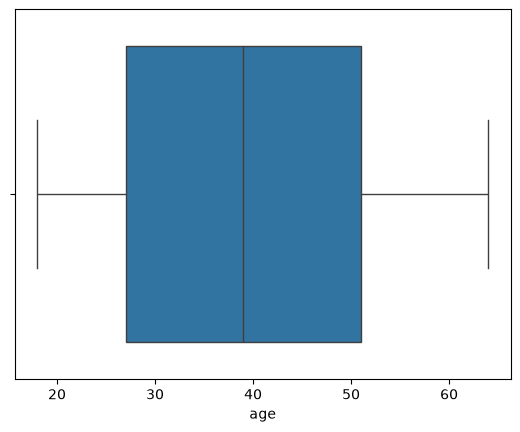

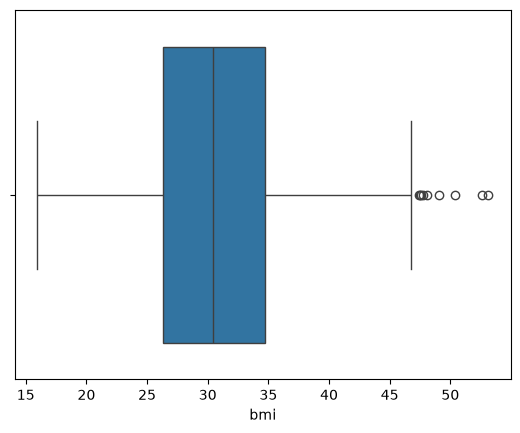

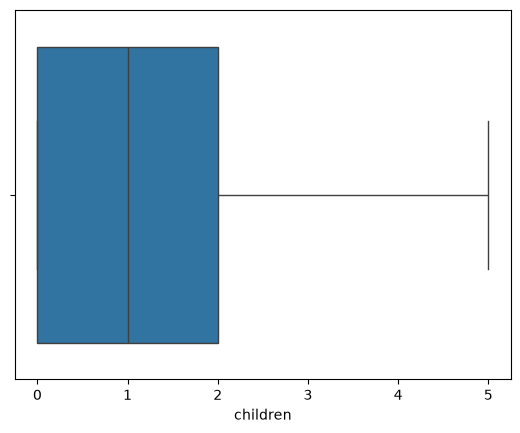

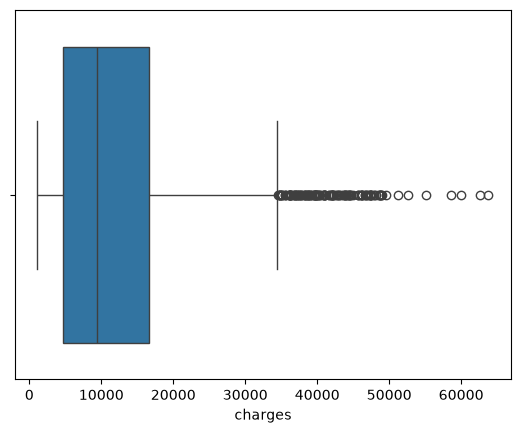

In [7]:
numeric_cols=df.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
    sns.boxplot(data=df, x=col)
    plt.show()



### Observation
- Charges and BMI contain Outliers but it will be retained as these are original values

## Univariate Analysis

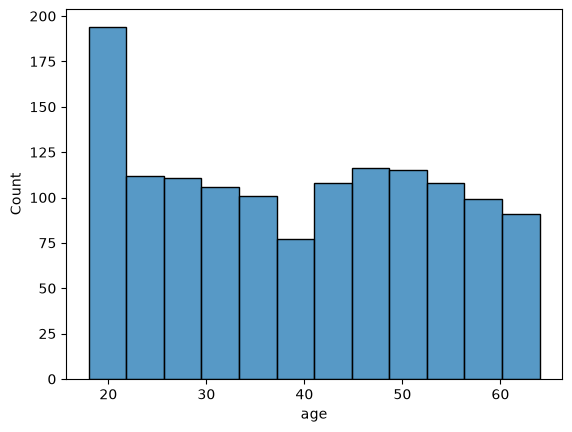

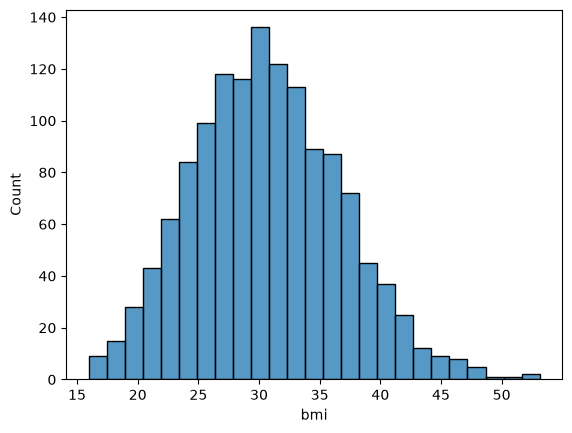

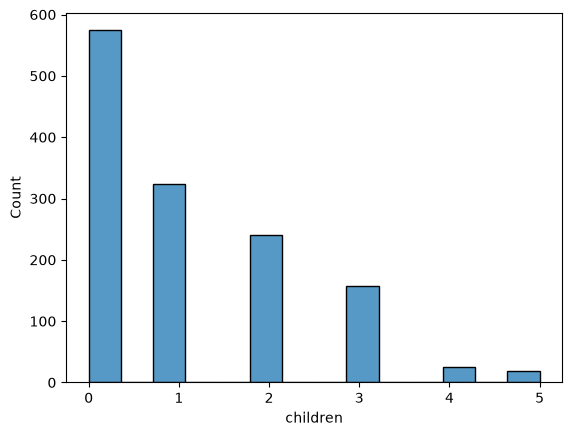

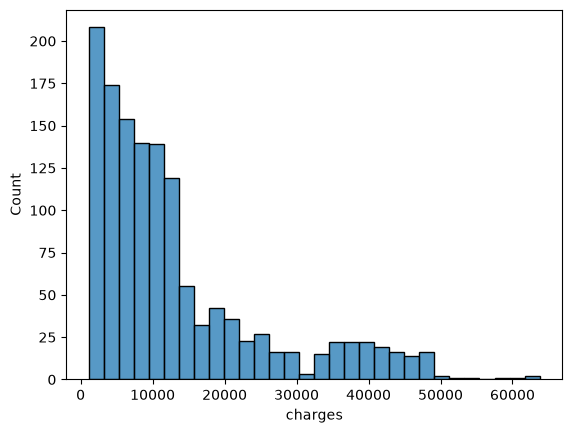

In [8]:
for cols in numeric_cols:
    sns.histplot(data=df,x=cols)
    plt.show()

### Observation:
- Age ranges from 18 to 64 years with more individuals in the range of 18 to 21 age groups, remaining ages are evenly distributed.
- BMI Values are concentrated between 22 to 37 and the graph is slightly right skewed.
- Most individuals have 0 to 1 Children.
- Charges are highly right skewed.

## Categorical Analysis

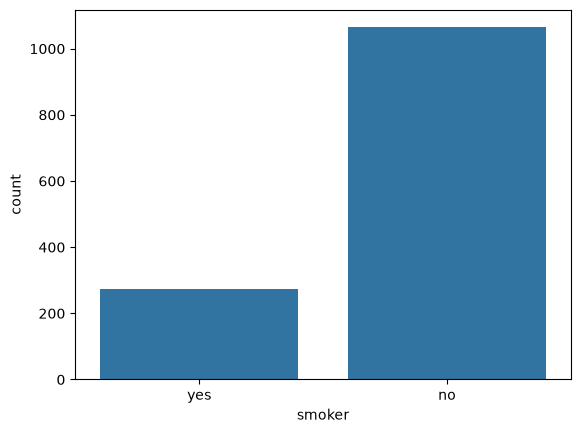

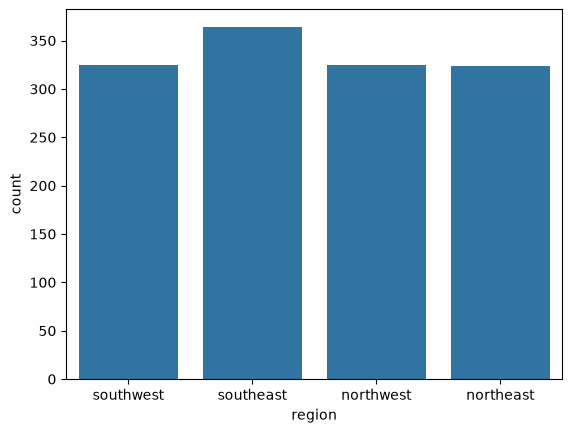

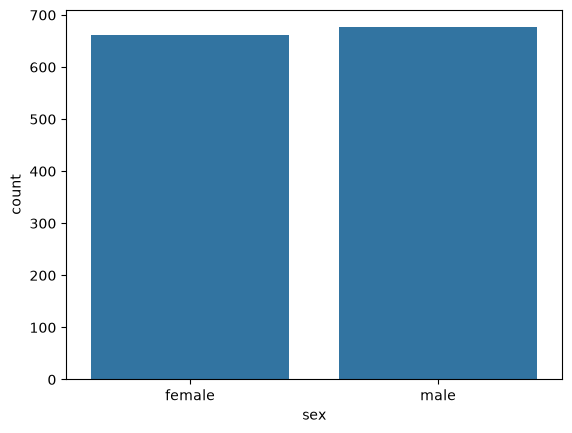

In [9]:
sns.countplot(x=df["smoker"])
plt.show()
sns.countplot(x=df["region"])
plt.show()
sns.countplot(x=df["sex"])
plt.show()

    


### Observation:
- Most of the individuals are non somkers
- The four regions are fairy balanced
- The dataset contains the balanced distribution of males and females

## Correlation analysis

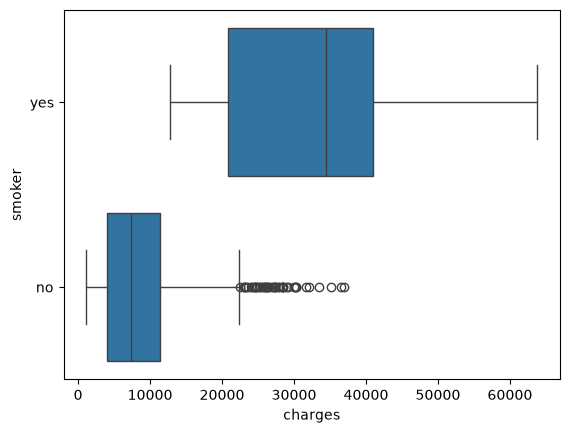

In [10]:
sns.boxplot(data=df,x='charges',y='smoker')
plt.show()

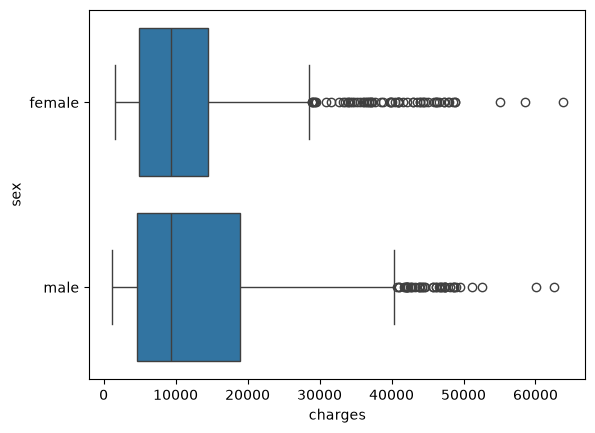

In [11]:
sns.boxplot(data=df,x='charges',y='sex')
plt.show()

## Encoding smoker column

In [12]:
df['smoker']=df['smoker'].map({'yes' : 1, 'no' : 0})


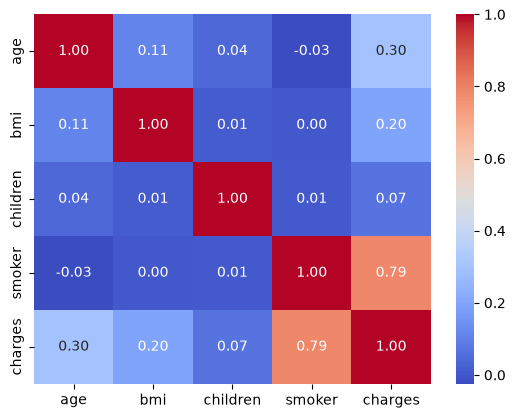

In [13]:
numeric_cols=df.select_dtypes(include=['float64','int64']).columns

corr= df[numeric_cols].corr()
sns.heatmap(corr, annot=True,cmap='coolwarm',fmt='.2f')
plt.show()

### Observation:
- Smokers has the strongest positive correlation with insurance charges.
- Age has moderate positive influence on insurance charges
- BMI has weak positive correlation with insurance charges
- Children have the minor positive influence on insurance charges

## Summary
Overall, the dataset is clean and well structured with no missing values, duplicates or inconsistent or invalid values.The distributions of numerical and catgorical data is analyzed and some outlliers are find in BMI and charges but these are the original values so we retain them, we will use a algorithm that can handle these outliers. So now this dataset is ready for preprocessing